In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
def show_fig(df):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Soft grid lines
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Plot 'Delay (sec)' on the left axis
    ax1.set_xlabel('Array Size')
    ax1.set_ylabel('Delay (sec)')
    line1, = ax1.plot(df['Array Size'], df['Delay (sec)'], label='Delay (sec)')
    ax1.tick_params(axis='y')
    ax1.tick_params(axis='x')

    # Plot 'CPU Temperature (C)' on the right axis
    ax2 = ax1.twinx()  
    ax2.set_ylabel('CPU Temperature (°C)')
    line2, = ax2.plot(df['Array Size'], df['CPU Temperature (C)'], color='orange', label='CPU Temperature (°C)', alpha=0.5)
    ax2.tick_params(axis='y')

    # Combine legends with a clean, light styling
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    # Custom title and layout adjustment
    plt.title('Performance Metrics vs. Array Size')
    plt.show()

# Measurement on noisy laptop

System settings

| Property | Value |
|----------|-------|
| Benchmark | Merge Sort |
| CPU | Intel® Core™ i7-6700HQ |
| Architecture | x86_64 |
| Physical Cores | 4 |
| Logical CPUs | 8 |
| Threads per Core | 2 |
| Base Frequency | 2.60 GHz |
| Maximum Frequency | 3.50 GHz |
| L1d Cache | 128 KiB |
| L1i Cache | 128 KiB |
| L2 Cache | 1 MiB |
| L3 Cache | 6 MiB |
| Memory | 12 GiB RAM, 4 GiB Swap |
| Operating System | Ubuntu 25.10 |
| Kernel | Linux 6.17.0-14-generic |
| Compiler | GCC 15.2.0 |
| Compiler Flags | `-O2` |

In [10]:
noisy = pd.read_csv('measurements_noisy.csv')
noisy

,Array Size,Delay (sec),CPU Temperature (C)
0,1,0.000000,49.0
1,20001,0.002278,49.0
2,40001,0.005453,49.0
3,60001,0.009425,49.0
4,80001,0.015302,49.0
...,...,...,...
295,5900001,1.009961,89.0
296,5920001,1.010727,91.0
297,5940001,1.030964,91.0
298,5960001,1.003402,91.0


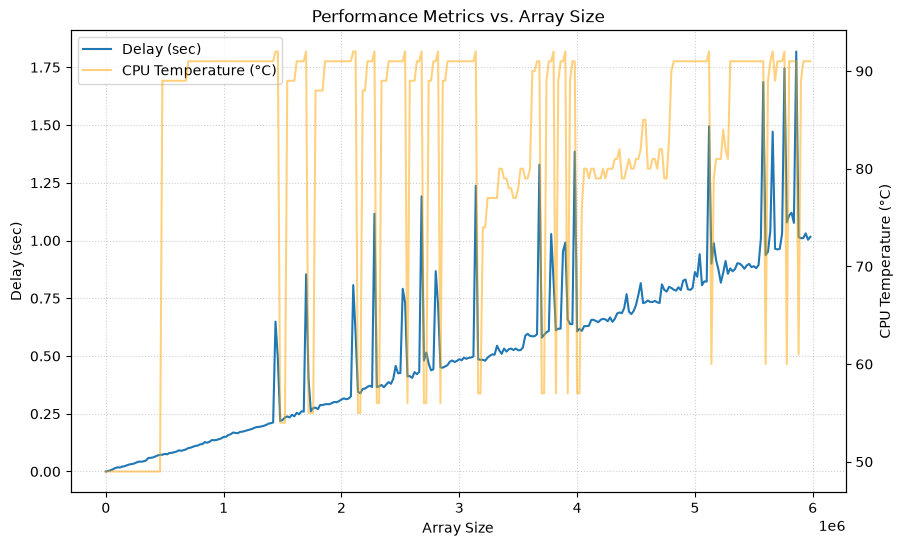

In [11]:
show_fig(noisy)

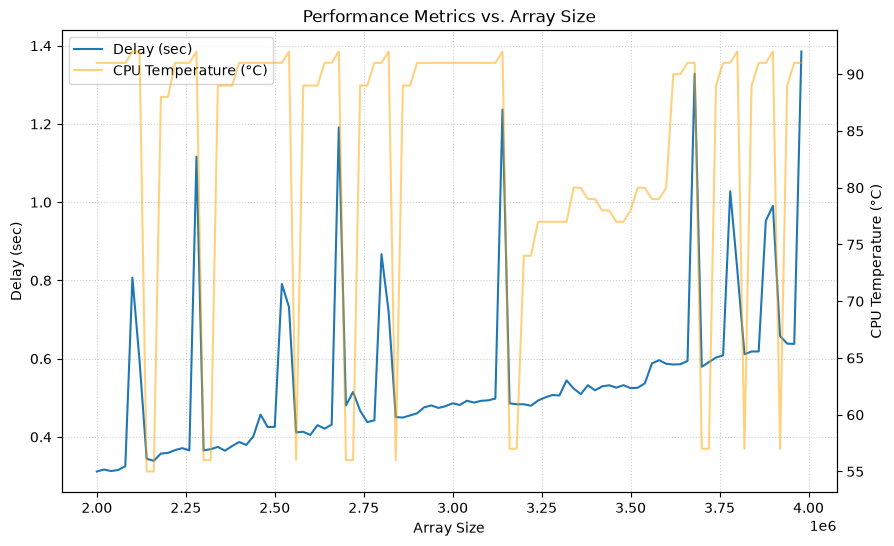

In [12]:
lower_bound = noisy['Array Size'] > 2 * 10**6
upper_bound = noisy['Array Size'] < 4 * 10**6

new_df = noisy[lower_bound & upper_bound]
show_fig(new_df)

# Measurement without noisy

To quiesce the system for these experiments, the following actions were recommended and implemented:
*   **Shut down external interference:** All other applications were closed, daemons and cron jobs were shut down, and the network was disconnected.
*   **Hands off:** No interaction with the mouse or keyboard occurred during measurements, as these generate frequent interrupts that disrupt timing.
*   **Disable dynamic hardware scaling:** Features like DVFS, Turbo Boost, and hyperthreading were disabled to ensure the processor maintained a constant frequency.
*   **Isolate the process:** To avoid Core 0's interrupt traffic, the program was "pinned" to specific cores using the `taskset` utility, preventing the operating system from moving threads between cores during execution.

In [13]:
quiesce = pd.read_csv('measurements_quiesce.csv')
quiesce

,Array Size,Delay (sec),CPU Temperature (C)
0,1,0.000000,43.0
1,20001,0.002764,43.0
2,40001,0.005678,43.0
3,60001,0.008870,43.0
4,80001,0.011700,43.0
...,...,...,...
295,5900001,1.113559,66.0
296,5920001,1.118135,66.0
297,5940001,1.121932,66.0
298,5960001,1.125589,66.0


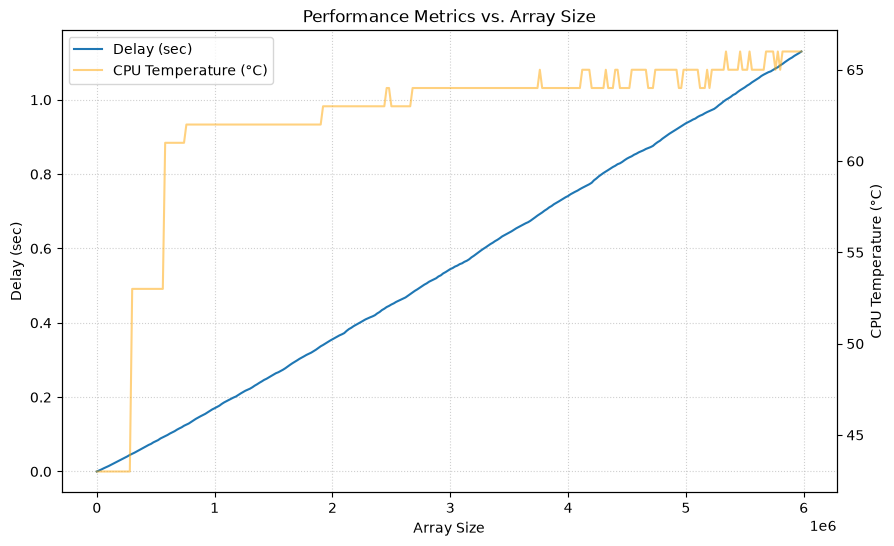

In [14]:
show_fig(quiesce)